In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_token_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"

In [2]:
def get_vectorized_murphy(y_true_multiclasse, y_prob_matriz, top_n=600, n_bins=10):
    """
    Calcula as métricas de Murphy de forma vetorizada, corrigindo o
    shape de arrays dinâmicos e espelhando a discretização exata do pd.cut.
    """
    N_amostras = len(y_true_multiclasse)
    if N_amostras == 0:
        return pd.DataFrame()

    # 1. Identificar Top Tokens presentes estritamente neste slice
    tokens, counts = np.unique(y_true_multiclasse, return_counts=True)
    sort_idx = np.argsort(-counts)

    top_tokens_ids = tokens[sort_idx][:top_n]
    top_counts = counts[sort_idx][:top_n]

    # A CORREÇÃO CRÍTICA DO SHAPE:
    actual_n = len(top_tokens_ids)

    # 2. Isolar matrizes para os tokens filtrados
    P = y_prob_matriz[:, top_tokens_ids]
    Y = (y_true_multiclasse[:, None] == top_tokens_ids).astype(float)

    # 3. Taxas Base e Incerteza
    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    # 4. Discretização exata equivalente ao pd.cut(include_lowest=True)
    bin_edges = np.linspace(0, 1, n_bins + 1)
    # digitize com right=True aloca valores <= à borda direita do bin
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    # Vetores dimensionados corretamente para o slice atual
    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = (bins == b) # booleano (N_amostras, actual_n)
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        # np.where é mais seguro e direto que multiplicar float por bool
        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        true_fraction = np.zeros(actual_n)
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras
        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid])**2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid])**2

    brier_score = reliability - resolution + uncertainty

    return pd.DataFrame({
        'token_id': top_tokens_ids,
        'frequencia': top_counts,
        'brier_score_multinomial': brier_score,
        'reliability_erro': reliability,
        'resolution_poder': resolution,
        'uncertainty_caos': uncertainty
    })

def get_vectorized_murphy_all_classes(y_true_multiclasse, y_prob_matriz, classes=None, n_bins=10):
    """
    Calcula a decomposição de Murphy considerando todas as classes possíveis.
    Isso evita perder reliability de classes não observadas no y_true do grupo,
    mas que receberam probabilidade positiva do modelo.
    """
    N_amostras = len(y_true_multiclasse)

    if N_amostras == 0:
        return pd.DataFrame()

    if classes is None:
        classes = np.arange(y_prob_matriz.shape[1])

    classes = np.asarray(classes)

    P = y_prob_matriz[:, classes]
    Y = (y_true_multiclasse[:, None] == classes).astype(float)

    base_rates = Y.mean(axis=0)
    uncertainty = base_rates * (1 - base_rates)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    bins = np.digitize(P, bin_edges[1:], right=True)
    bins = np.clip(bins, 0, n_bins - 1)

    actual_n = len(classes)

    resolution = np.zeros(actual_n)
    reliability = np.zeros(actual_n)

    for b in range(n_bins):
        mask = bins == b
        bin_counts = mask.sum(axis=0)

        valid = bin_counts > 0

        prob_mean = np.zeros(actual_n)
        true_fraction = np.zeros(actual_n)

        prob_mean[valid] = np.where(mask, P, 0.0).sum(axis=0)[valid] / bin_counts[valid]
        true_fraction[valid] = np.where(mask, Y, 0.0).sum(axis=0)[valid] / bin_counts[valid]

        weight = bin_counts / N_amostras

        reliability[valid] += weight[valid] * (prob_mean[valid] - true_fraction[valid]) ** 2
        resolution[valid] += weight[valid] * (true_fraction[valid] - base_rates[valid]) ** 2

    brier_decomp = reliability - resolution + uncertainty

    frequencia = Y.sum(axis=0).astype(int)

    return pd.DataFrame({
        "token_id": classes,
        "frequencia": frequencia,
        "brier_score_multinomial": brier_decomp,
        "reliability_erro": reliability,
        "resolution_poder": resolution,
        "uncertainty_caos": uncertainty
    })

In [3]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}

# tokens_info = tokens_info\
# .query("hpts != 0 or vpts != 0 or limhteam != 0 or limvteam != 0")\
# .to_dict(orient = 'index')


In [10]:
with open(data_folder + 'data_token_features.pkl', 'rb') as f:
    df_token_features = pickle.load(f)


In [4]:
%run 01_functions_training.ipynb
#%run drive/MyDrive/mestrado_final_files/notebooks/01_functions_training.ipynb

In [5]:
list_models = [item for item in os.listdir(models_token_folder) if "NGramModel" in item and ".pth" in item]

In [6]:
VOCAB_SIZE = 601

In [16]:
def get_match_splits(df, num_secs = 300):
    num_breaks = [i for i in range(0, 7201, num_secs)]
    num_labels = [str(i) + "-" + str(j) for i, j in zip(num_breaks[:-1], num_breaks[1:])]
    num_breaks[0] -= 1
    num_breaks[-1] += 1
    return df.assign(cat_time = lambda df: pd.cut(df["remaining_time"], bins = num_breaks, labels = num_labels))

def multiclass_cross_entropy(y_true, y_prob, eps=1e-15):
    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(np.log(y_prob[np.arange(len(y_true)), y_true]))

def process_group(idx, dev_y, all_probs, classes = None, get_bs_global = False, get_ce = False, get_mae = False):
    y_true_sub = dev_y[idx]
    y_prob_sub = all_probs[idx]

    if classes is None:
        classes = np.arange(y_prob_sub.shape[1])

    df_res = get_vectorized_murphy_all_classes(y_true_multiclasse=y_true_sub, y_prob_matriz = y_prob_sub, classes = classes, n_bins = 10)

    if get_bs_global:
        bs_global = multiclass_brier_score(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["brier_score_multinomial"] = bs_global

    if get_ce:
        ce_global = multiclass_cross_entropy(y_true = y_true_sub, y_prob = y_prob_sub)
        df_res["cross_entropy"] = ce_global

    if get_mae:
        expected_output = y_prob_sub @ np.arange(y_prob_sub.shape[1])
        mae_global = np.mean(np.abs(y_true_sub - expected_output))
        df_res["mae"] = mae_global

    return df_res

def multiclass_brier_score(y_true, y_prob):
    """
    Calcula o Brier Score Global para classificação multiclasse.

    y_true: array 1D com os índices reais dos tokens, shape (N,)
    y_prob: array 2D com as probabilidades preditas (softmax), shape (N, C)
    """
    N_amostras, n_classes = y_prob.shape

    # Cria a representação one-hot dos alvos (0.0 para erro, 1.0 para acerto)
    y_true_one_hot = np.zeros_like(y_prob, dtype=float)
    y_true_one_hot[np.arange(N_amostras), y_true] = 1.0

    # Calcula o erro quadrático, soma por classe e tira a média por amostra
    brier_score = np.mean(np.sum((y_prob - y_true_one_hot)**2, axis=1))

    return brier_score

In [17]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [7]:
len(list_models)


240

In [20]:
df_token_features.assign(cat_dif = lambda df: df["token_state"] % 9)["cat_dif"].value_counts()

,count
cat_dif,
4,774583
7,316939
5,268674
6,265311
1,240671
3,239378
2,224450
8,146528
0,89043


In [21]:
xdf = df_token_features\
.query("period <= 4")\
.assign(cat_dif = lambda df: df["token_state"] % 9)\
.pipe(get_match_splits, num_secs = 200)\
.assign(t1 = lambda df: df["cat_time"].astype("str").str.split("-").str[0].astype("int") / 10)\
.groupby(["period", "t1", "cat_dif"], as_index = False, dropna = False).size()\
.assign(total = lambda df: df.groupby(["period", "t1"])["size"].transform("sum"))\
.assign(perc = lambda df: 100 * df["size"] / df["total"])\
.assign(cat_dif = lambda df: "cat_dif_" + df["cat_dif"].astype("str"))\
.pivot_table(index = ["period", "t1"], columns = "cat_dif", values = "perc")\
.fillna(0)\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])


<Axes: >

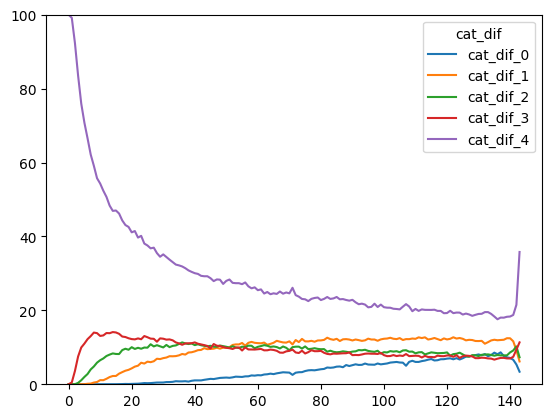

In [22]:
xdf.reset_index(drop = True)[["cat_dif_0", "cat_dif_1", "cat_dif_2", "cat_dif_3", "cat_dif_4"]].plot(ylim = [0, 100])

# \
# .iloc[-60:]

In [ ]:
list_decomposition_time = []
list_decomposition_dif = []
list_decomposition_time_dif = []
list_decomposition_season = []

group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel" in item and ".pth" in item and str_season in item]

    # 1. PREPARAÇÃO DOS DADOS DA TEMPORADA (FORA DO LOOP DE MODELOS)
    df_ = df_token_features.query("season == @season").query("season_split == 'dev'")

    # Processamento temporal feito uma única vez por temporada
    df_ = (df_
           .assign(period = lambda df: np.where(df["period"] > 4, 5, df["period"]))
           .pipe(get_match_splits, num_secs = 200))\
    .assign(cat_time = lambda df: df["cat_time"].astype("str"))\
    .assign(cat_dif = lambda df: df["token_state"] % 9)

    # Conversão eficiente de memória
    dev_tkn = torch.from_numpy(np.stack(df_["token_features"].values)).to(torch.int64)
    dev_num = torch.from_numpy(np.stack(df_["numerical_features"].values)).to(torch.float32) # Numéricas geralmente usam float32
    dev_y = df_["target_tokens"].values

    print(season)
    for model_filename in tqdm.tqdm(list_models):

        CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
        EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
        variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
        num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
        num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
        dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
        layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

        token_model = NGramModel(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE, embedding_dim = EMBEDDING_LAYER_SIZE,
                                num_hidden_neurons = num_hidden_neurons, num_layers = num_layers, activation = nn.GELU,
                                dropout_rate = dropout_rate, use_layer_norm = layer_norm)

        token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
        token_model.eval()

        # 2. INFERÊNCIA
        with torch.no_grad():
            # Ajuste condicional para modelos que requerem variáveis numéricas
            if variables_config > 0: # Ajuste esta condição conforme a sua lógica de arquiteturas
                output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:], dev_num)
            else:
                output_model = token_model(dev_tkn[:, -CONTEXT_SIZE:])

            all_probs = torch.softmax(output_model, dim = 1).cpu().numpy()

        # 3. EXTRAÇÃO POR TEMPO
        results_time = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            results_time.append(res_df)

        df_decomposition_by_time = pd.concat(results_time, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time = df_decomposition_by_time\
        .groupby(group_variables1 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time[group_variables1 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time.append(df_resultados_time)

        # 3. EXTRAÇÃO POR DIF
        results_dif = []
        for name, group_idx in df_.groupby(["season_split", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["cat_dif"] = name[1]
            results_dif.append(res_df)

        df_decomposition_by_dif = pd.concat(results_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_dif = df_decomposition_by_dif\
        .groupby(group_variables2 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_dif[group_variables2 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_dif.append(df_resultados_dif)

        # 3. EXTRAÇÃO POR TIME E DIF
        results_time_dif = []
        for name, group_idx in df_.groupby(["season_split", "period", "cat_time", "cat_dif"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            res_df["season_split"] = name[0]
            res_df["period"] = name[1]
            res_df["cat_time"] = name[2]
            res_df["cat_dif"] = name[3]
            results_time_dif.append(res_df)

        df_decomposition_by_time_dif = pd.concat(results_time_dif, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_time_dif = df_decomposition_by_time_dif\
        .groupby(group_variables3 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_time_dif[group_variables3 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_time_dif.append(df_resultados_time_dif)

        # 4. EXTRAÇÃO POR SPLIT
        results_split = []
        for name, group_idx in df_.groupby(["season_split"], observed = True).indices.items():
            res_df = process_group(group_idx, dev_y = dev_y, all_probs = all_probs, get_bs_global = True, get_ce = True)
            # Como agrupou por apenas 1 coluna, name pode não ser tupla. Usamos diretamente.
            res_df["season_split"] = name
            results_split.append(res_df)

        df_decomposition_by_split = pd.concat(results_split, ignore_index = True)\
        .assign(context_size = CONTEXT_SIZE, embedding_layer_size = EMBEDDING_LAYER_SIZE,
                set_covariables = variables_config, num_hidden_neurons = num_hidden_neurons,
                num_layers = num_layers, dropout_rate = dropout_rate, layer_norm = layer_norm,
                seasondata = str_season)

        df_resultados_split = df_decomposition_by_split\
        .groupby(group_variables4 + ["seasondata"], as_index = False, dropna = False)\
        [["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
        .merge(df_decomposition_by_split[group_variables4 + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
        .assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

        list_decomposition_season.append(df_resultados_split)

        # # 5. SALVAR ARQUIVOS (Removida a linha duplicada de dict_results)
        # dict_results = {"dev_time": df_decomposition_by_time, "season_split": df_decomposition_by_split}
        # results_filename = model_filename.replace("_parameters.pth", "_brier_metrics.pkl")

        # with open(models_token_metrics_folder + results_filename, 'wb') as f:
        #     pickle.dump(dict_results, f)

2018-19


100%|██████████| 48/48 [15:44<00:00, 19.69s/it]


2019-20


100%|██████████| 48/48 [14:10<00:00, 17.72s/it]


2020-21


100%|██████████| 48/48 [13:43<00:00, 17.15s/it]


2021-22


100%|██████████| 48/48 [15:43<00:00, 19.66s/it]


2022-23


100%|██████████| 48/48 [15:08<00:00, 18.93s/it]


In [24]:
df_murphy_decomposition_by_time = pd.concat(list_decomposition_time, ignore_index = True)
df_murphy_decomposition_by_time.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time.parquet", index = False, compression = "zstd")


In [25]:
df_murphy_decomposition_by_dif = pd.concat(list_decomposition_dif, ignore_index = True)
df_murphy_decomposition_by_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_dif.parquet", index = False, compression = "zstd")

In [26]:
df_murphy_decomposition_by_time_dif = pd.concat(list_decomposition_time_dif, ignore_index = True)
df_murphy_decomposition_by_time_dif.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_time_dif.parquet", index = False, compression = "zstd")

In [27]:
df_murphy_decomposition_by_season_split = pd.concat(list_decomposition_season, ignore_index = True)
df_murphy_decomposition_by_season_split.to_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split.parquet", index = False, compression = "zstd")


In [8]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel" in item and ".pkl" in item and str_season in item]

    for file in tqdm.tqdm(list_models):
        with open(models_token_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["num_parameters"]))



100%|██████████| 48/48 [00:37<00:00,  1.27it/s]


In [9]:
df_parameters = pd.DataFrame(list_num_parametros, columns = ["modelname", "num_parameters"])

In [10]:
df_parameters\
.assign(seasondata = lambda df: df["modelname"].str.split("_").str[1].str.replace("seasondata", "").astype("int"))\
.assign(context_size = lambda df: df["modelname"].str.split("_").str[2].str.replace("context", "").astype("int"))\
.assign(embedding_layer_size = lambda df: df["modelname"].str.split("_").str[3].str.replace("embedding", "").astype("int"))\
.assign(num_layers = lambda df: df["modelname"].str.split("_").str[4].str.replace("numlayers", "").astype("int"))\
.assign(num_hidden_neurons = lambda df: df["modelname"].str.split("_").str[5].str.replace("numneurons", "").astype("int"))\
.assign(dropout_rate = lambda df: df["modelname"].str.split("_").str[6].str.replace("dropout", "").replace("no", 0).astype("int") / 10)\
.assign(layer_norm = lambda df: df["modelname"].str.split("_").str[7].str.replace("layernorm", ""))\
.assign(set_covariables = lambda df: df["modelname"].str.split("_").str[8].str.replace("setcovariables", "").replace("\.pkl", "", regex = True).astype("int"))\
.drop(columns = "modelname")\
.sort_values("num_parameters")\
.drop_duplicates(["context_size", "embedding_layer_size", "num_layers", "num_hidden_neurons", "layer_norm", "set_covariables"])\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "set_covariables"], columns = ["num_layers", "layer_norm"], values = "num_parameters", aggfunc= lambda x: x)\
.reset_index()

num_layers context_size embedding_layer_size num_hidden_neurons  \
layer_norm                                                        
0                     1                   32                 50   
1                     1                   64                 50   
2                     3                   32                 50   
3                     3                   64                 50   
4                     5                   32                 50   
5                     5                   64                 50   

num_layers set_covariables      3             5         
layer_norm                  False   True  False   True  
0                        0  56633  56897  61733  62197  
1                        0  77465  77793  82565  83093  
2                        0  59833  60225  64933  65525  
3                        0  83865  84449  88965  89749  
4                        0  63033  63553  68133  68853  
5                        0  90265  91105  95365  96405

In [ ]:
# df_murphy_decomposition_by_season_split\
# .assign(token = lambda df: df["token_id"].map(integer_to_token))\
# .sort_values("reliability_erro")

In [ ]:
# df_murphy_decomposition_by_time\
# .assign(token = lambda df: df["token_id"].map(integer_to_token))\
# .query("token.str.contains('_3')").round(5)\
# .sort_values("reliability_erro")

In [ ]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_season_split.parquet")

In [ ]:
group_variables = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [ ]:
df_resultados1 = df_murphy_decomposition_by_season_split\
.groupby(group_variables + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_season_split[group_variables + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

df_resultados2 = df_resultados1\
.groupby(group_variables, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))



In [ ]:
df_resultados1[["seasondata", "uncertainty_caos"]].drop_duplicates()

In [ ]:
df_resultados1[["seasondata", "uncertainty_caos"]].drop_duplicates().describe()

In [ ]:
sum([0.963789, 0.962171, 0.962774, 0.961949, 0.962596]) / 5

In [ ]:
df_resultados2\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

In [ ]:
df_resultados2\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

In [ ]:
df_resultados2\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["embedding_layer_size", "num_hidden_neurons", "dropout_rate", "layer_norm", "num_layers"], columns = "context_size" , values = "metrica", aggfunc = lambda x: x)\
.reset_index()

In [ ]:
df_resultados2\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["layer_norm", "dropout_rate"], as_index = False)["index"].describe()

################################################# cross entropy mean
# context_size
# 1	16.0	40.500	4.760952	33.0	36.75	40.5	44.25	48.0
# 3	16.0	18.625	8.624577	 5.0	12.50	19.0	24.75	32.0
# 5	16.0	14.375	9.891916	 1.0	 6.25	14.0	21.25	31.0

# embedding_layer_size
# 32	24.0	24.708333	14.555678	1.0	12.50	25.0	36.00	48.0
# 64	24.0	24.291667	13.731839	2.0	14.25	24.0	36.25	47.0

# num_layers
# 3	24.0	22.708333	13.898637	1.0	12.75	20.5	36.50	44.0
# 5	24.0	26.291667	14.165111	3.0	13.25	28.5	34.75	48.0

# dropout_rate
# 0.0	24.0	17.875	14.081479	 1.0	 6.75	12.5	34.25	40.0
# 0.3	24.0	31.125	10.518359	16.0	22.75	28.5	42.25	48.0

# layer_norm
# False	24.0	23.625	15.645009	1.0	8.25	24.5	37.25	48.0
# True	24.0	25.375	12.416022	7.0	14.75	25.0	34.50	46.0

# 	layer_norm	dropout_rate   count	     mean	      std	 min	  25%	 50%	  75%	 max
# 0	     False	         0.0	12.0	15.916667	16.211434	 1.0	 3.75	 7.5	35.50	40.0
# 1	     False	         0.3	12.0	31.333333	10.923980	19.0	23.75	26.5	43.25	48.0
# 2	      True	         0.0	12.0	19.833333	11.975986	 7.0	11.50	14.5	33.25	39.0
# 3	      True	         0.3	12.0	30.916667	10.578351	16.0	21.75	30.0	41.25	46.0

In [ ]:
df_resultados2\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["context_size"], as_index = False)["index"].describe()

# context_size
# 0	1	16.0	38.2500	 6.547264	29.0	32.75	37.5	44.25	48.0
# 1	3	16.0	17.5625	11.183135	 1.0	 9.25	16.0	24.50	38.0
# 2	5	16.0	17.6875	11.987320	 2.0	 8.75	17.0	22.75	42.0

# embedding_layer_size
# 0	32	24.0	24.458333	14.823539	1.0	10.75	25.5	36.50	48.0
# 1	64	24.0	24.541667	13.445475	3.0	14.75	24.0	34.75	46.0

# num_layers
# 0	3	24.0	21.916667	13.134477	1.0	14.25	20.5	33.25	44.0
# 1	5	24.0	27.083333	14.631463	5.0	12.50	28.5	38.75	48.0

# dropout_rate
# 0	0.0	24.0	16.583333	12.257798	 1.0	 6.75	12.5	30.25	36.0
# 1	0.3	24.0	32.416667	10.930280	16.0	22.75	32.5	42.25	48.0

# layer_norm
# 0	False	24.0	22.75	15.134901	1.0	 6.75	24.5	32.50	48.0
# 1	True	24.0	26.25	12.847771	9.0	14.75	24.5	38.25	47.0

#   layer_norm	dropout_rate	count	     mean	      std	 min	  25%	 50%	 75%	      max
# 0	False	0.0	12.0	14.083333	14.336592	 1.0	 3.75	 6.5	31.25	36.0
# 1	False	0.3	12.0	31.416667	10.466035	21.0	23.75	26.5	43.25	48.0
# 2	True	0.0	12.0	19.083333	 9.746406	 9.0	11.75	14.5	29.25	35.0
# 3	True	0.3	12.0	33.416667	11.750886	16.0	19.75	38.5	41.25	47.0


In [ ]:
df_resultados1\
.pivot_table(index = group_variables, columns =  "seasondata", values = "bss")\
.reset_index()

In [ ]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "murphy_decomposition_by_time.parquet")

In [ ]:
df_murphy_decomposition_by_time.columns

In [ ]:
group_variables = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

In [ ]:
df_murphy_decomposition_by_time

In [ ]:
df_resultados3 = df_murphy_decomposition_by_time\
.groupby(group_variables + ["seasondata"], as_index = False, dropna = False)\
[["reliability_erro", "resolution_poder", "uncertainty_caos"]].sum()\
.merge(df_murphy_decomposition_by_time[group_variables + ["seasondata", "cross_entropy", "brier_score_multinomial"]].drop_duplicates(), how = "left")\
.assign(bss = lambda df: 1 - (df["brier_score_multinomial"] / df["uncertainty_caos"]))

In [ ]:
df_resultados4 = df_resultados3\
.groupby(group_variables, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

In [ ]:
df_resultados4\
.query("cat_time == '0-200' & period == 4")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "cross_entropy_mean")\
.plot(ax = ax)

ax.set_ylim(2, 4)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Entropia cruzada ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Entropia cruzada")
#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bss_mean")\
.plot(ax = ax)

ax.set_ylim(-0.1, 0.4)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Skill Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Skill Score")
ax.axhline(0, zorder = -3, linestyle = '--', color = 'gray')
plt.tight_layout()



In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (10, 5))

df_resultados4\
.query("context_size == 5 & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
.query("period <= 4")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.pivot_table(index = ["t1"], columns = "period", values = "bs_mean")\
.plot(ax = ax)

ax.set_ylim(0.5, 1)
ax.invert_xaxis()
ax.set_xlim(720, -10)  # 12:00 até 0:00
ax.set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))

# Grade e legenda
ax.grid(True, alpha=0.25)
ax.legend(title="Período", frameon=True)

# Título e rótulos
ax.set_title("Brier Score ao longo do tempo por período",
             fontsize = 13,pad = 12)

ax.set_xlabel("Tempo restante")
ax.set_ylabel("Brier Score")

# Grade leve para leitura
ax.grid(True, alpha=0.25)

#ax.axhline(1 - (1/600), zorder = -3)
plt.tight_layout()



In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size in [1, 3, 5] & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [0, 0.25]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score da melhor configuração da arquitetura A para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size in [1, 3, 5] & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [1.5, 4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize=15, y=0.98)

# legenda única embaixo
fig.suptitle("Entropia cruzada da melhor configuração da arquitetura A para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size in [1, 3, 5] & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "reliability_erro_mean")\
    .plot(ax = ax[i], legend=False)

    ax[i].set_ylim(0.0, 0.12)
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Calibração")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)


# legenda única embaixo
fig.suptitle("Calibração da melhor configuração da arquitetura A para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

#legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

In [ ]:
fig, ax = plt.subplots(1, 4, figsize = (15, 5))

for i in range(4):
    df_resultados4\
    .query("context_size in [1, 3, 5] & embedding_layer_size == 64 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "resolution_poder_mean")\
    .plot(ax = ax[i], legend=False)

    bounds_y = [0, 0.4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Resolução")
        ax[i].tick_params(axis="y", labelleft=True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis="y", left=False, labelleft=False)

# título geral
fig.suptitle("Resolução da melhor configuração da arquitetura A para predição do próximo token de evento ao longo do tempo restante por período", fontsize = 15, y = 0.92)

#legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
plt.show()

In [ ]:
df_resultados3.query("cat_time in ['0-200'] & period == 4")\
.pivot_table(index = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"], columns =  "seasondata", values = "bss")\
.reset_index()